# Clasificación de noticias mediante procesamiento de lenguaje natural

## Entregables esperados
- Exploración del dataset y balance de clases
- Preprocesamiento del texto
- Vectorización y entrenamiento de al menos tres modelos
- Validación cruzada y métricas
- Análisis de errores y selección del modelo final


## 1. Configuración inicial


In [46]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

BASE_DIR = Path.cwd()
FIGURES_DIR = BASE_DIR / "figuras"
FIGURES_DIR.mkdir(exist_ok=True)

TRAIN_PATH = BASE_DIR / "ag-news-classificacion/train.csv"
TEST_PATH = BASE_DIR / "ag-news-classificacion/test.csv"

TRAIN_PATH, TEST_PATH


(WindowsPath('C:/Users/FoodLovers/Documents/Unir-Notes/Maestría-Ingeniería-de-Software/07-Fundamentos-IA/Actividades/Actividad-02/ag-news-classificacion/train.csv'),
 WindowsPath('C:/Users/FoodLovers/Documents/Unir-Notes/Maestría-Ingeniería-de-Software/07-Fundamentos-IA/Actividades/Actividad-02/ag-news-classificacion/test.csv'))

## 2. Descarga de recursos de NLTK

Ejecuta esta celda una sola vez si aún no tienes descargados estos recursos.


In [47]:
# nltk.download("stopwords")
# nltk.download("punkt")
# nltk.download("punkt_tab")
# nltk.download("wordnet")
# nltk.download("omw-1.4")


## 3. Carga del dataset


In [48]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# train_df.head()
test_df.head()


,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


## 4. Exploración inicial

Revisa estructura, columnas, nulos y distribución de etiquetas.


In [49]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nColumnas train:", train_df.columns.tolist())
print("\nInfo train:")
train_df.info()
print("\nColumnas test:", test_df.columns.tolist())
print("\nInfo test:")
test_df.info()


Train shape: (120000, 3)
Test shape: (7600, 3)

Columnas train: ['Class Index', 'Title', 'Description']

Info train:
<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Class Index  120000 non-null  int64
 1   Title        120000 non-null  str  
 2   Description  120000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.7 MB

Columnas test: ['Class Index', 'Title', 'Description']

Info test:
<class 'pandas.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Class Index  7600 non-null   int64
 1   Title        7600 non-null   str  
 2   Description  7600 non-null   str  
dtypes: int64(1), str(2)
memory usage: 178.3 KB


In [50]:
print("\n nulls Train_df:")
print("\n",train_df.isnull().sum())
print("\n nulls test_df:")
test_df.isnull().sum()



 nulls Train_df:

 Class Index    0
Title          0
Description    0
dtype: int64

 nulls test_df:


Class Index    0
Title          0
Description    0
dtype: int64

## 5. Preparación de texto y etiquetas

In [51]:
TEXT_COL_1 = "Title"
TEXT_COL_2 = "Description"
LABEL_COL = "Class Index"

CLASS_NAMES = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}
CLASS_ORDER = [CLASS_NAMES[label] for label in sorted(CLASS_NAMES)]

train_df["text"] = train_df[TEXT_COL_1].fillna("") + " " + train_df[TEXT_COL_2].fillna("")
test_df["text"] = test_df[TEXT_COL_1].fillna("") + " " + test_df[TEXT_COL_2].fillna("")

train_df["label"] = train_df[LABEL_COL]
test_df["label"] = test_df[LABEL_COL]
train_df["label_name"] = train_df["label"].map(CLASS_NAMES)
test_df["label_name"] = test_df["label"].map(CLASS_NAMES)

train_df[["label", "label_name", "text"]].head()


,label,label_name,text
0,3,Business,Wall St. Bears Claw Back Into the Black (Reute...
1,3,Business,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Business,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,Business,"Oil prices soar to all-time record, posing new..."


In [52]:
test_df[["label", "label_name", "text"]].head()

,label,label_name,text
0,3,Business,Fears for T N pension after talks Unions repre...
1,4,Sci/Tech,The Race is On: Second Private Team Sets Launc...
2,4,Sci/Tech,Ky. Company Wins Grant to Study Peptides (AP) ...
3,4,Sci/Tech,Prediction Unit Helps Forecast Wildfires (AP) ...
4,4,Sci/Tech,Calif. Aims to Limit Farm-Related Smog (AP) AP...


In [53]:
train_df["label"].value_counts().sort_index()

label
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64

In [54]:
test_df["label"].value_counts().sort_index()

label
1    1900
2    1900
3    1900
4    1900
Name: count, dtype: int64

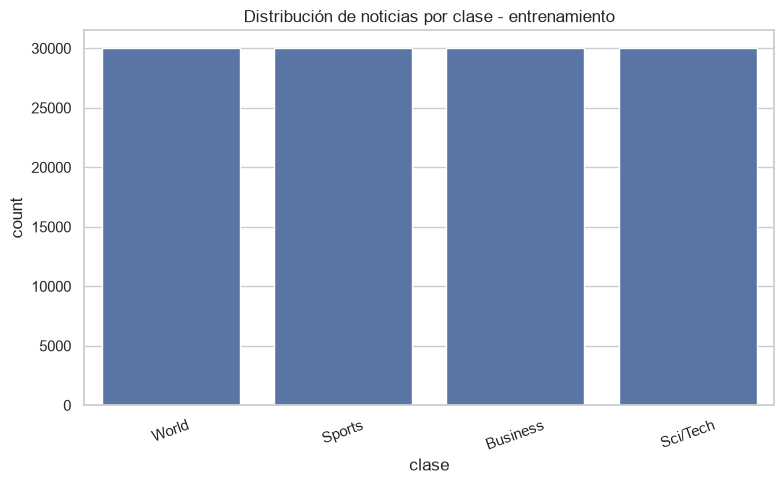

In [55]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x="label_name", order=CLASS_ORDER)
plt.title("Distribución de noticias por clase - entrenamiento")
plt.xlabel("clase")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribucion_clases_train.png", dpi=300)
plt.show()


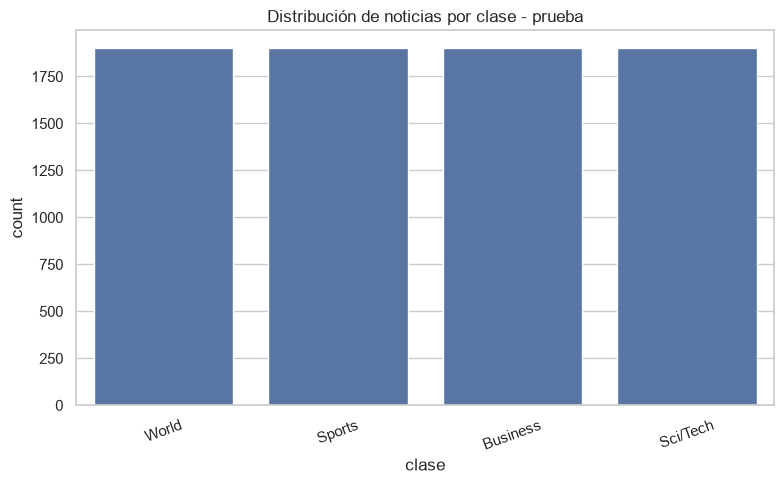

In [56]:
plt.figure(figsize=(8, 5))
sns.countplot(data=test_df, x="label_name", order=CLASS_ORDER)
plt.title("Distribución de noticias por clase - prueba")
plt.xlabel("clase")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribucion_clases_test.png", dpi=300)
plt.show()


In [57]:
train_df["text_length"] = train_df["text"].str.len()
train_df["text_length"].describe()


count    120000.000000
mean        236.460025
std          66.529799
min          17.000000
25%         196.000000
50%         232.000000
75%         266.000000
max        1012.000000
Name: text_length, dtype: float64

In [58]:
test_df["text_length"] = test_df["text"].str.len()
test_df["text_length"].describe()


count    7600.000000
mean      235.290395
std        65.299706
min       100.000000
25%       196.750000
50%       231.000000
75%       266.000000
max       892.000000
Name: text_length, dtype: float64

## 6. Limpieza y normalización del texto

In [59]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return " ".join(tokens)


In [60]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

train_df[["text", "clean_text"]].head()


,text,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall bear claw back black reuters reuters shor...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle look toward commercial aerospace reute...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil economy cloud stock outlook reuters reuter...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halt oil export main southern pipeline re...
4,"Oil prices soar to all-time record, posing new...",oil price soar time record posing new menace e...


In [61]:

test_df[["text", "clean_text"]].head()


,text,clean_text
0,Fears for T N pension after talks Unions repre...,fear pension talk union representing worker tu...
1,The Race is On: Second Private Team Sets Launc...,race second private team set launch date human...
2,Ky. Company Wins Grant to Study Peptides (AP) ...,company win grant study peptide company founde...
3,Prediction Unit Helps Forecast Wildfires (AP) ...,prediction unit help forecast wildfire barely ...
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,calif aim limit farm related smog southern cal...


## 7. Definición de entrenamiento y prueba

In [62]:
X_train = train_df["clean_text"]
y_train = train_df["label"]
X_test = test_df["clean_text"]
y_test = test_df["label"]

len(X_train), len(X_test)


(120000, 7600)

## 8. Vectorización con TF-IDF


In [63]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_tfidf.shape, X_test_tfidf.shape


((120000, 20000), (7600, 20000))

## 9. Entrenamiento de modelos supervisados


In [64]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)


## 10. Evaluación de métricas

Reporta Accuracy, Precision, Recall y F1-score. Después interpreta los resultados en una celda Markdown.


In [65]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted"
    )
    return {
        "modelo": name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

results = [
    evaluate_model("Naive Bayes", y_test, nb_pred),
    evaluate_model("Logistic Regression", y_test, lr_pred),
    evaluate_model("LinearSVC", y_test, svm_pred)
]

results_df = pd.DataFrame(results)
results_df


,modelo,accuracy,precision,recall,f1_score
0,Naive Bayes,0.900263,0.899927,0.900263,0.899832
1,Logistic Regression,0.913684,0.913537,0.913684,0.913513
2,LinearSVC,0.918289,0.918251,0.918289,0.918199


In [66]:
results_df.to_csv(BASE_DIR / "metricas_modelos.csv", index=False)


## 11. Classification report del mejor modelo

In [67]:
predictions = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "LinearSVC": svm_pred,
}

best_model_name = results_df.sort_values("f1_score", ascending=False).iloc[0]["modelo"]
best_pred = predictions[best_model_name]
labels = sorted(CLASS_NAMES)
target_names = [CLASS_NAMES[label] for label in labels]

print(best_model_name)
print(classification_report(y_test, best_pred, labels=labels, target_names=target_names))


LinearSVC
              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.88      0.89      0.88      1900
    Sci/Tech       0.90      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



## 12. Matriz de confusión

Genera la matriz de confusión del modelo final y comenta qué clases se confunden más.


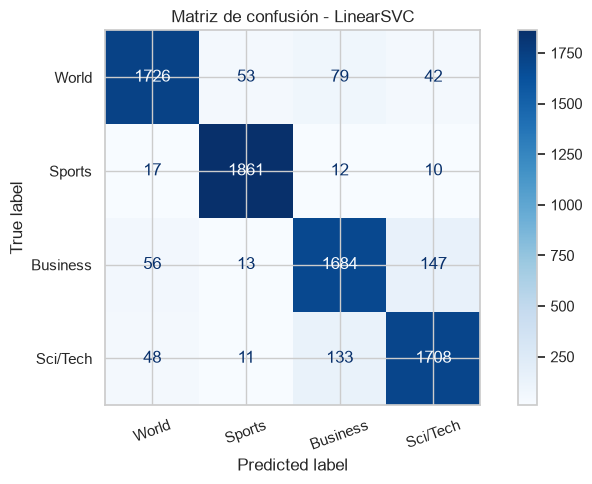

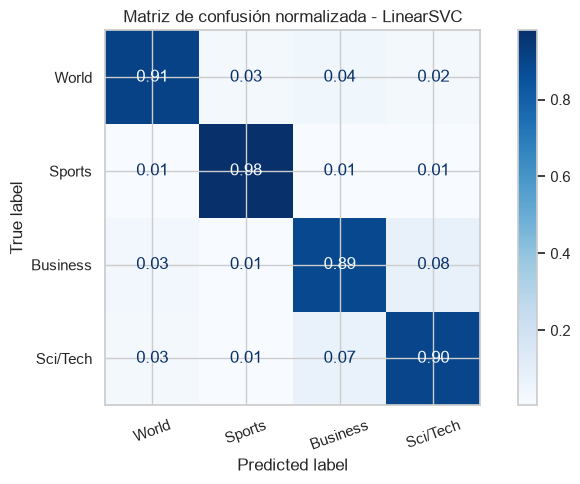

In [68]:
labels = sorted(CLASS_NAMES)
class_names = [CLASS_NAMES[label] for label in labels]

cm = confusion_matrix(y_test, best_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"matriz_confusion_{best_model_name.lower()}.png", dpi=300)
plt.show()

cm_norm = confusion_matrix(y_test, best_pred, labels=labels, normalize="true")
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp_norm.plot(cmap="Blues", values_format=".2f")
plt.title(f"Matriz de confusión normalizada - {best_model_name}")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"matriz_confusion_{best_model_name.lower()}_normalizada.png", dpi=300)
plt.show()


## 13. Validación cruzada

Usa pipelines para evitar fugas de información durante la vectorización.


In [69]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3, max_df=0.95)),
    ("model", MultinomialNB())
])

lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3, max_df=0.95)),
    ("model", LogisticRegression(max_iter=1000))
])

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3, max_df=0.95)),
    ("model", LinearSVC())
])


In [70]:
cv_nb = cross_val_score(nb_pipeline, X_train, y_train, cv=5, scoring="f1_weighted")
cv_lr = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring="f1_weighted")
cv_svm = cross_val_score(svm_pipeline, X_train, y_train, cv=5, scoring="f1_weighted")

cv_results = pd.DataFrame([
    {"modelo": "Naive Bayes", "cv_f1_mean": cv_nb.mean(), "cv_f1_std": cv_nb.std()},
    {"modelo": "Logistic Regression", "cv_f1_mean": cv_lr.mean(), "cv_f1_std": cv_lr.std()},
    {"modelo": "LinearSVC", "cv_f1_mean": cv_svm.mean(), "cv_f1_std": cv_svm.std()}
])
cv_results


,modelo,cv_f1_mean,cv_f1_std
0,Naive Bayes,0.897162,0.008342
1,Logistic Regression,0.903738,0.007320
2,LinearSVC,0.897629,0.008769


## 14. Análisis de errores

Revisa ejemplos mal clasificados y comenta patrones observados.


In [71]:
errors_df = pd.DataFrame({
    "texto_original": test_df["text"].values,
    "texto_limpio": X_test.values,
    "real": y_test.values,
    "real_nombre": y_test.map(CLASS_NAMES).values,
    "predicho": best_pred,
    "predicho_nombre": pd.Series(best_pred).map(CLASS_NAMES).values
})

errors_df = errors_df[errors_df["real"] != errors_df["predicho"]]
errors_df.head(20)


,texto_original,texto_limpio,real,real_nombre,predicho,predicho_nombre
19,"Storage, servers bruise HP earnings update Ear...",storage server bruise earnings update earnings...,4,Sci/Tech,3,Business
23,Some People Not Eligible to Get in on Google I...,people eligible get google ipo google billed i...,4,Sci/Tech,3,Business
24,Rivals Try to Turn Tables on Charles Schwab By...,rival try turn table charles schwab michael li...,4,Sci/Tech,3,Business
36,Venezuela Prepares for Chavez Recall Vote Supp...,venezuela prepares chavez recall vote supporte...,1,World,3,Business
41,Retailers Vie for Back-To-School Buyers (Reute...,retailer vie back school buyer reuters reuters...,3,Business,4,Sci/Tech
47,Dell Exits Low-End China Consumer PC Market H...,dell exit low end china consumer market hong k...,4,Sci/Tech,3,Business
56,India's Tata expands regional footprint via Na...,india tata expands regional footprint via nats...,1,World,3,Business
79,Live: Olympics day four Richard Faulds and Ste...,live olympics day four richard fauld stephen p...,1,World,2,Sports
83,Intel to delay product aimed for high-definiti...,intel delay product aimed high definition tv s...,3,Business,4,Sci/Tech
100,"Olympic history for India, UAE An Indian army ...",olympic history india uae indian army major sh...,2,Sports,1,World


In [72]:
errors_df.to_csv(BASE_DIR / "ejemplos_errores.csv", index=False)


## 15. Comparación final y selección del modelo


In [73]:
final_comparison = results_df.merge(cv_results, on="modelo", how="left")
final_comparison


,modelo,accuracy,precision,recall,f1_score,cv_f1_mean,cv_f1_std
0,Naive Bayes,0.900263,0.899927,0.900263,0.899832,0.897162,0.008342
1,Logistic Regression,0.913684,0.913537,0.913684,0.913513,0.903738,0.007320
2,LinearSVC,0.918289,0.918251,0.918289,0.918199,0.897629,0.008769
